Introduction

This project performs binary image classification (Cat vs Dog) using Transfer Learning with the VGG16 pretrained model in PyTorch.

Instead of training a CNN from scratch, the pretrained convolutional layers of VGG16 are reused while replacing the classifier for the binary classification task.

Key Features
Transfer Learning using VGG16
PyTorch implementation
Binary Classification
Model Checkpoint Saving
Confusion Matrix
Classification Report
Prediction Script

In [82]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset , DataLoader
from torchvision.datasets import ImageFolder
from torchvision import transforms

from sklearn.metrics import classification_report , confusion_matrix
import matplotlib.pyplot as plt

In [83]:
# import kagglehub

# # Download latest version
# path = kagglehub.dataset_download("bhavikjikadara/dog-and-cat-classification-dataset")

# print("Path to dataset files:", path)


In [84]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

print(device)

mps


In [85]:
path = "../"

In [86]:
transform = transforms.Compose([
    transforms.Resize(224),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225])
])

In [87]:
dataset = ImageFolder(f"{path}/PetImages" , transform=transform)

In [88]:
from torch.utils.data import random_split

train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_dataset, test_dataset = random_split(
    dataset,
    [train_size, test_size]
)


In [ ]:
train_loader = DataLoader(dataset=train_dataset , batch_size = 32 , shuffle=True)
test_loader = DataLoader(dataset=test_dataset , batch_size = 32 , shuffle=True)

Importing Model

In [90]:
import torchvision.models as models
vgg16 = models.vgg16(pretrained = True)


In [91]:
vgg16

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [92]:
vgg16.classifier

Sequential(
  (0): Linear(in_features=25088, out_features=4096, bias=True)
  (1): ReLU(inplace=True)
  (2): Dropout(p=0.5, inplace=False)
  (3): Linear(in_features=4096, out_features=4096, bias=True)
  (4): ReLU(inplace=True)
  (5): Dropout(p=0.5, inplace=False)
  (6): Linear(in_features=4096, out_features=1000, bias=True)
)

In [93]:
for params in vgg16.features.parameters():
  params.requires_grad = False

In [94]:
vgg16.classifier = nn.Sequential(
    nn.Linear(25088 , 1024),
    nn.ReLU(),
    nn.Dropout(0.5),

    nn.Linear(1024 , 512),
    nn.ReLU(),
    nn.Dropout(0.5),

    nn.Linear(512 , 32),
    nn.ReLU(),
    nn.Linear(32 , 1)
)

In [95]:
vgg16

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [96]:
vgg16 = vgg16.to(device)

In [110]:
learning_rate = 0.0001
epochs = 5

In [98]:
loss_fn = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(vgg16.classifier.parameters() , lr=learning_rate , weight_decay=1e-4)

In [99]:
train_losses = []
# train_losses.append(epoch_loss)

In [111]:
for epoch in range(epochs):
  print("start")
  total_loss_in_epoch = 0
  for input , target in train_loader:
    optimizer.zero_grad()
    input , target = input.to(device) , target.unsqueeze(1).float().to(device)

    y_pred = vgg16(input)
    loss = loss_fn(y_pred , target)

    loss.backward()
    optimizer.step()
    total_loss_in_epoch += loss.item()
  total_loss_in_epoch /= len(train_loader)
  train_losses.append(total_loss_in_epoch)
  print(f"Epoch: {epoch+1}, Loss: {total_loss_in_epoch}")

start


/Users/priyanshuchaudhary/Priyanshu/coding/Project/CNN_Using_Transfer_learning/.venv/lib/python3.13/site-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Epoch: 1, Loss: 0.01602593418880715
start
Epoch: 2, Loss: 0.005548740485751477
start
Epoch: 3, Loss: 0.008170791997516426
start
Epoch: 4, Loss: 0.005197492010022325
start
Epoch: 5, Loss: 0.004456949612224844


In [112]:
vgg16.eval()
correct = 0
total = 0
y_pred = []
y_true = []
with torch.no_grad():
  for image , target in test_loader:
    image , target = image.to(device) , target.float().to(device)

    logit = vgg16(image)
    pred = torch.sigmoid(logit)
    y_hat = (pred > 0.5).float()

    correct += (y_hat == target.unsqueeze(1)).sum().item()
    total += target.size(0)

    y_pred.extend(y_hat.cpu().numpy())
    y_true.extend(target.cpu().numpy())

accuracy = (correct / total)*100
print(f"Model accuracy is : {accuracy}")

Model accuracy is : 98.68


In [113]:
print(classification_report(
    y_true=y_true,
    y_pred=y_pred,
    target_names=["cat" , "dog"]
))

              precision    recall  f1-score   support

         cat       0.98      0.99      0.99      2450
         dog       0.99      0.98      0.99      2550

    accuracy                           0.99      5000
   macro avg       0.99      0.99      0.99      5000
weighted avg       0.99      0.99      0.99      5000



[[2428   22]
 [  44 2506]]


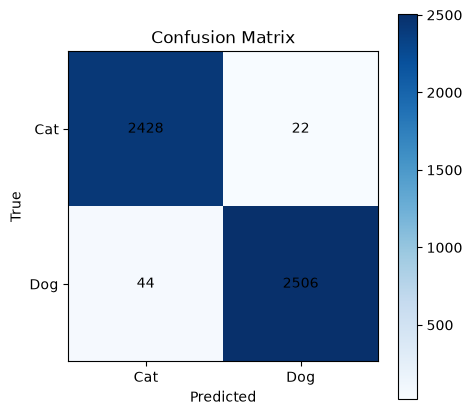

<Figure size 640x480 with 0 Axes>

In [114]:
cm = confusion_matrix(y_true , y_pred)
print(cm)

plt.figure(figsize=(5,5))

plt.imshow(cm, cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")

plt.xticks([0,1],["Cat","Dog"])
plt.yticks([0,1],["Cat","Dog"])

for i in range(2):
    for j in range(2):
        plt.text(j,i,str(cm[i,j]),
                 ha='center',
                 va='center',
                 color='black')

plt.colorbar()
plt.show()
plt.savefig("results/confusion_matrix.png")


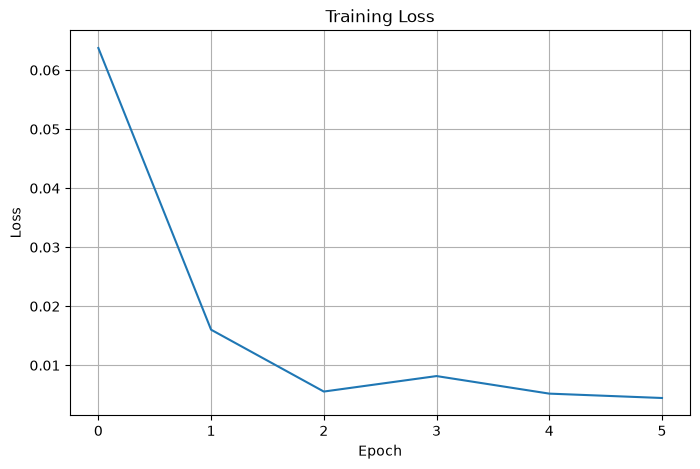

<Figure size 640x480 with 0 Axes>

In [117]:
plt.figure(figsize=(8,5))

plt.plot(train_losses)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")

plt.grid()

plt.show()
plt.savefig("results/loss_curve.png")

In [ ]:
torch.save(vgg16.state_dict(), "checkpoint/cat_vs_dog_model.pth")